# 01. Разведочный анализ данных (EDA)

В этом ноутбуке:
- загрузка данных
- первичный осмотр (структура, типы, статистики)
- визуализация распределения целевой переменной
- анализ пропусков
- анализ выбросов (boxplot для возраста)
- корреляционный анализ

### 1. Загрузка данных и первичный осмотр

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Настройки вывода
pd.set_option('display.width', 300)

# Создаём папку для графиков
FIGURES_DIR = '../reports/figures/01_eda'
os.makedirs(FIGURES_DIR, exist_ok=True)

# Загрузка данных
df = pd.read_csv('../data/raw/cs-training.csv')

# Удаляем столбец-идентификатор (создаём чистую копию)
df_clean = df.drop('Unnamed: 0', axis=1)

print("Первые 10 строк:")
print(df_clean.head(10))

print("\nИнформация о датасете и типах данных:")
print(df.info())

print("\nОсновные статистики (по полезным признакам):")
print(df_clean.describe())

Первые 10 строк:
   SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines  age  NumberOfTime30-59DaysPastDueNotWorse    DebtRatio  MonthlyIncome  NumberOfOpenCreditLinesAndLoans  NumberOfTimes90DaysLate  NumberRealEstateLoansOrLines  NumberOfTime60-89DaysPastDueNotWorse  NumberOfDependents
0                 1                              0.766127   45                                     2     0.802982         9120.0                               13                        0                             6                                     0                 2.0
1                 0                              0.957151   40                                     0     0.121876         2600.0                                4                        0                             0                                     0                 1.0
2                 0                              0.658180   38                                     1     0.085113         3042.0                              

### 2. Распределение целевой переменной

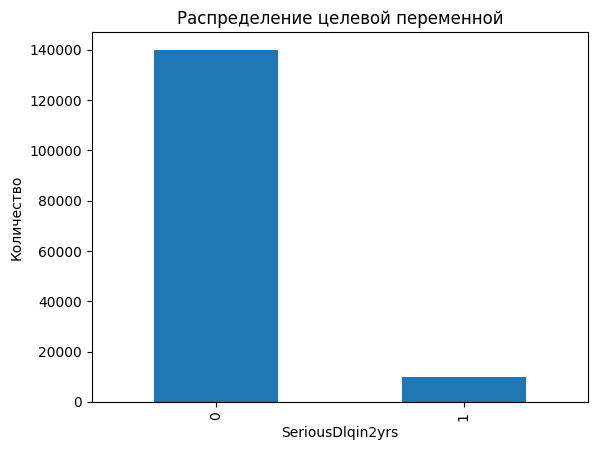

In [2]:
# График баланса классов
df['SeriousDlqin2yrs'].value_counts().plot(kind='bar')
plt.title('Распределение целевой переменной')
plt.xlabel('SeriousDlqin2yrs')
plt.ylabel('Количество')
plt.savefig(os.path.join(FIGURES_DIR, 'class_balance.png'), bbox_inches='tight')
plt.show()

### 3. Анализ пропусков

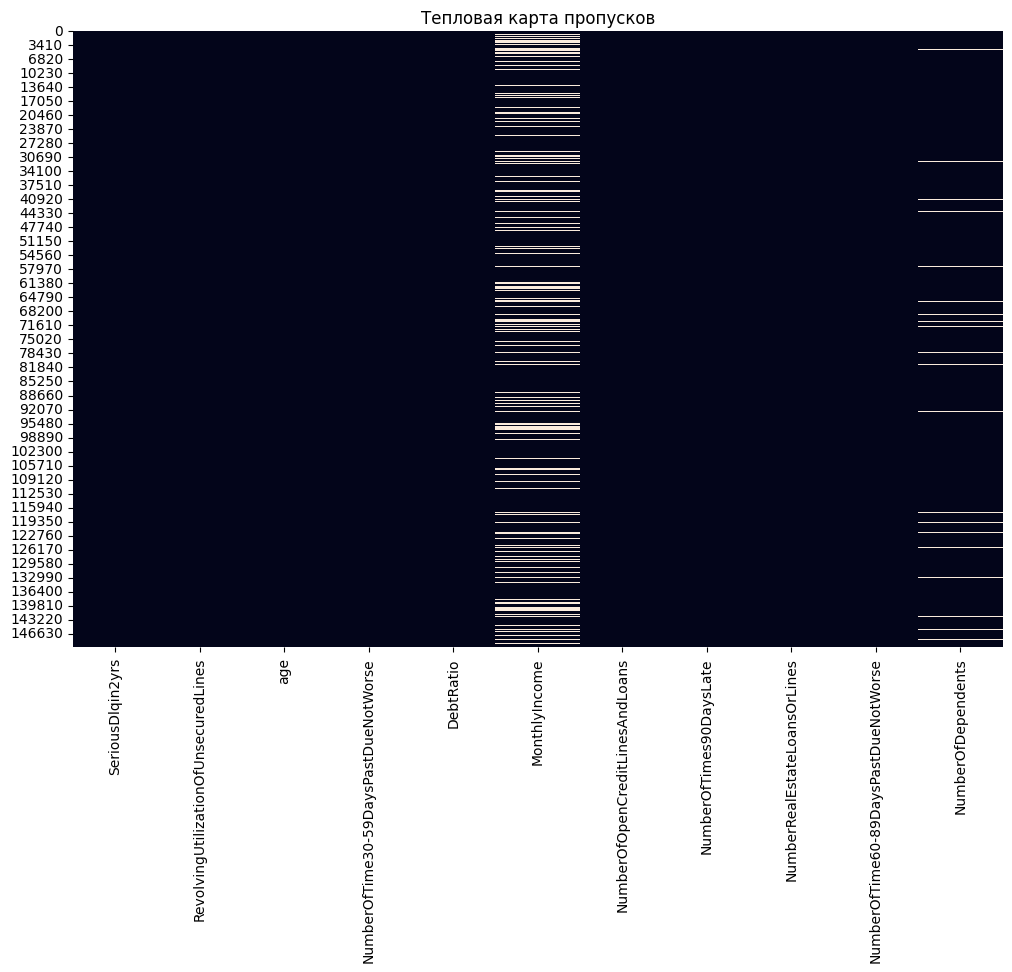

In [3]:
# Тепловая карта пропусков (используем df_clean, где уже удалён идентификатор)
plt.figure(figsize=(12,8))
sns.heatmap(df_clean.isnull(), cbar=False)
plt.title('Тепловая карта пропусков')
plt.savefig(os.path.join(FIGURES_DIR, 'missing_heatmap.png'), bbox_inches='tight')
plt.show()

### 4. Анализ выбросов (на примере возраста)

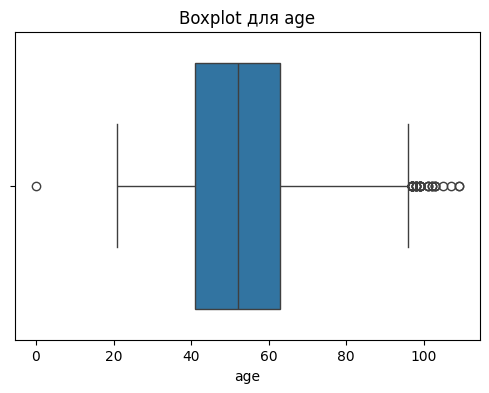

Нижняя теоретическая граница: 8.00
Верхняя теоретическая граница: 96.00
Значение нижнего уса: 21
Значение верхнего уса: 96


In [4]:
# Boxplot для возраста
plt.figure(figsize=(6,4))
sns.boxplot(x=df['age'])
plt.title('Boxplot для age')
plt.savefig(os.path.join(FIGURES_DIR, 'boxplot_age.png'), bbox_inches='tight')
plt.show()

# Расчёт границ "усов"
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

whisker_low = df[df['age'] >= lower_bound]['age'].min()
whisker_high = df[df['age'] <= upper_bound]['age'].max()

print(f"Нижняя теоретическая граница: {lower_bound:.2f}")
print(f"Верхняя теоретическая граница: {upper_bound:.2f}")
print(f"Значение нижнего уса: {whisker_low}")
print(f"Значение верхнего уса: {whisker_high}")

### 5. Корреляционный анализ

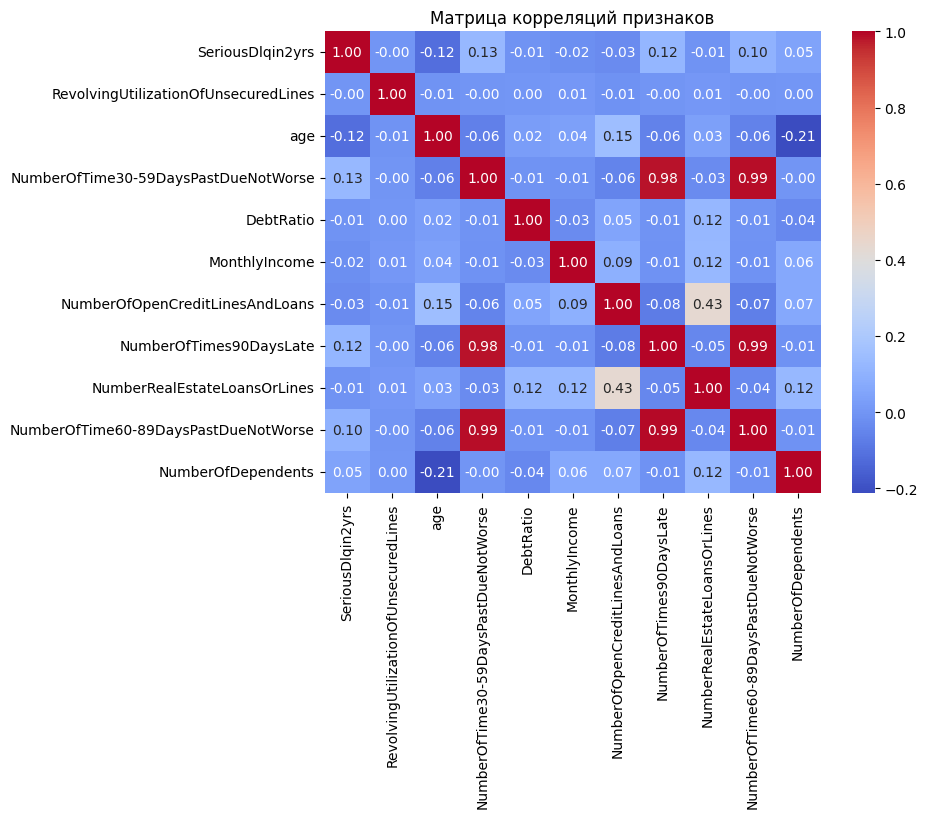

In [5]:
# Матрица корреляций (без идентификатора)
plt.figure(figsize=(8, 6))
sns.heatmap(df_clean.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Матрица корреляций признаков')
plt.savefig(os.path.join(FIGURES_DIR, 'corr_heatmap.png'), bbox_inches='tight')
plt.show()
